In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(1,'/Users/sadmin/Documents/MeerFish') # path to MeerFish code
import cosmo
import survey
import model
import fisher

f_tobsloss = 0.5 # fraction of observation time loss (XLP assumed 0.5)
N_dish = 60 # number of operational dishes out of full 64 in array (XLP assumed 60)

## parameters to include in Fisher forecast:
theta_ids = [\
    #r'$\overline{T}_{\rm HI}$',\
    #r'$b_1$',\
    #r'$b_2$',\
    #r'$b^\phi_1$',\
    #r'$b^\phi_2$',\
    #r'$f$',\
    #r'$\alpha_\perp$',\
    #r'$\alpha_\parallel$',\
    r'$A_{\rm BAO}$',\
    #r'$f_{\rm NL}$'\
    ]

Survey1_arg = 'MK_UHF' # MeerKLASS UHF-band IM survey
Survey2_arg = 'DESI_LRG' # DESI LRG galaxies
t_obs = 800 * (1-f_tobsloss) # total MeerKLASS observation time (with losses then applied)
A_sky = 4000 # original sky area
A_skyX = 3000 # sky area overlapping with DESI galaxies

ZesVersion = True # use Ze's (XLP) models for HI bias and \bar{T}_HI

kmax = 0.1/0.7 # [h/Mpc] matching Ze's (XLP) cut - beyond this non-linear/gridding and instrumental effects dominate

### Choose which power spectrum multipoles:
ells = [0] # just monopole (default)
#ells = [0,2,4] # first three noon-zero multipoles

### Show BAO wiggles detection approach demo:

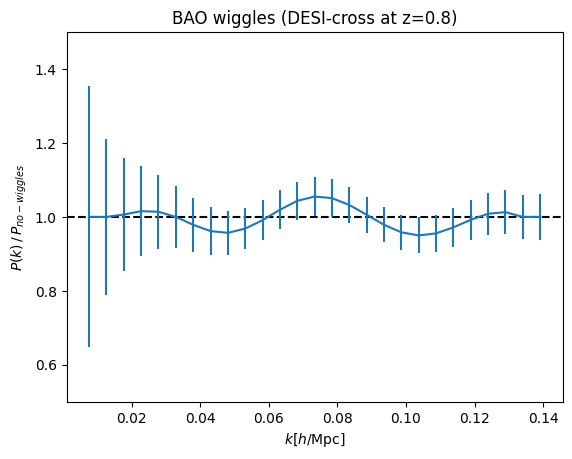

In [2]:
z = 0.8
deltaz = 0.2 # redshift width for each bin
zminzmax = [z-deltaz/2,z+deltaz/2] # use default

z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,t_tot=t_obs,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))
k_fg = 0 # explore this later
surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion) # set initial default cosmology
nuispars = 0,0,0 # ignore nuisance parameters throughout
Pmod = cosmo.MatterPk(z)
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=kmax,Taruya=True)

P_X = model.P_ell(0,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_err = model.sigma_ell_error(0,k,Pmod,cosmopars,surveypars,nuispars,'X')
P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)
plt.axhline(1,color='black',ls='--')
plt.errorbar(k,P_X/P_smooth,P_err/P_smooth)
plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z) 
plt.ylim(0.5,1.5)
plt.show()

### Reproduce Table 1 from XLP submission (using MeerFish):

In [3]:
years = ["2023–2024*", "2024–2025", "2025–2026", "2026–2027", "2027–2028"]
t_add = [380,500,500,550,570]
t_obss = np.cumsum(t_add) # cumulative observing time
A_skys = [1600,3600,5600,7800,10000]
zs = [0.43,0.61,0.8,1]
deltazs = [0.06,0.18,0.2,0.2,0.2]

BAO_SNR,BAO_SNR_x = np.zeros((len(t_add),len(zs))),np.zeros((len(t_add),len(zs)))
for i in range(len(t_add)):
    for j in range(len(zs)):
        sys.stdout.write(f"\r{i}, {j}")
        sys.stdout.flush()
                
        A_skyX = A_skys[i] * 3/4
        if A_skyX>3000: A_skyX = 3000
        if zs[j]<=0.8: Survey2_arg_j = 'DESI_LRG' # DESI LRG galaxies
        if zs[j]>0.8: Survey2_arg_j = 'DESI_ELG' # DESI ELG galaxies

        t_obs_i = t_obss[i] * (1-f_tobsloss) # apply observation time losses
        
        zminzmax = [zs[j]-deltazs[j]/2,zs[j]+deltazs[j]/2] # use default
        z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg_j,zminzmax=zminzmax,A_sky1=A_skys[i],A_skyX=A_skyX,t_tot=t_obs_i,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))

        surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
        cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion) # set initial default cosmology
        Pmod = cosmo.MatterPk(z)
    
        ### HI auto:
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky1,kmax=kmax,Taruya=True)
        F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
        C = fisher.FisherInverse(F)
        BAO_SNR[i,j] = 1/np.sqrt(C[-1][-1])

        ### Cross-correlation:
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=kmax,Taruya=True)
        F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
        C = fisher.FisherInverse(F)
        BAO_SNR_x[i,j] = 1/np.sqrt(C[-1][-1])


from IPython.display import Markdown, display
BAO_combined = np.sqrt(np.sum(BAO_SNR**2, axis=1)) # Combined in quadrature (typical for SNR)
BAO_combined_x = np.sqrt(np.sum(BAO_SNR_x**2, axis=1)) # Combined in quadrature (typical for SNR)

###########################################################################################
### Below is code only for generating table in notebook: 
###########################################################################################
### Auto-correlation:
display(Markdown(f"## Auto-correlation:"))
table = f"""
| Year | Obs. time [h] | Total area [deg$^2$] | BAO SNR z={zs[0]} | z={zs[1]} | z={zs[2]} | z={zs[3]} | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
"""
for i in range(len(years)):
    if i == 0: # Format obs time (first entry no "+")
        t_str = f"{t_add[i]}"
    else:
        t_str = f"+{t_add[i]}"
    table += (
        f"| {years[i]} | {t_str} | {A_skys[i]} | "
        f"{BAO_SNR[i,0]:.1f} | {BAO_SNR[i,1]:.1f} | "
        f"{BAO_SNR[i,2]:.1f} | {BAO_SNR[i,3]:.1f} | "
        f"{BAO_combined[i]:.1f} |\n"
    )
display(Markdown(table))

### Cross-correlation:
display(Markdown(f"## Cross-correlation (with DESI):"))
display(Markdown(f"Assumes maximum 75% of MeerKLASS area overlaps with DESI footprint, up to a maximum of 3,000deg$^2$ overlap. Hence diminishing increases are reached once all possible overlap has been observed."))
table = f"""
| Year | Obs. time [h] | Total area [deg$^2$] | BAO SNR z={zs[0]} | z={zs[1]} | z={zs[2]} | z={zs[3]} | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
"""
for i in range(len(years)):
    if i == 0: # Format obs time (first entry no "+")
        t_str = f"{t_add[i]}"
    else:
        t_str = f"+{t_add[i]}"
    table += (
        f"| {years[i]} | {t_str} | {A_skys[i]} | "
        f"{BAO_SNR_x[i,0]:.1f} | {BAO_SNR_x[i,1]:.1f} | "
        f"{BAO_SNR_x[i,2]:.1f} | {BAO_SNR_x[i,3]:.1f} | "
        f"{BAO_combined_x[i]:.1f} |\n"
    )
display(Markdown(table))

0, 3

/Users/sadmin/Documents/MeerFish/model.py:291: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  d2 = scipy.interpolate.UnivariateSpline(k, derivs[2], k=3, s=1)


4, 3

## Auto-correlation:


| Year | Obs. time [h] | Total area [deg$^2$] | BAO SNR z=0.43 | z=0.61 | z=0.8 | z=1 | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
| 2023–2024* | 380 | 1600 | 1.0 | 1.8 | 1.5 | 1.1 | 2.7 |
| 2024–2025 | +500 | 3600 | 1.4 | 3.0 | 2.6 | 2.0 | 4.6 |
| 2025–2026 | +500 | 5600 | 1.8 | 3.8 | 3.3 | 2.6 | 5.9 |
| 2026–2027 | +550 | 7800 | 2.3 | 4.4 | 4.1 | 3.3 | 7.2 |
| 2027–2028 | +570 | 10000 | 2.8 | 5.1 | 4.7 | 3.9 | 8.4 |


## Cross-correlation (with DESI):

Assumes maximum 75% of MeerKLASS area overlaps with DESI footprint, up to a maximum of 3,000deg$^2$ overlap. Hence diminishing increases are reached once all possible overlap has been observed.


| Year | Obs. time [h] | Total area [deg$^2$] | BAO SNR z=0.43 | z=0.61 | z=0.8 | z=1 | Combined |
|:----:|:-------------:|:--------------------:|:----------------:|:--------:|:--------:|:--------:|:--------:|
| 2023–2024* | 380 | 1600 | 1.2 | 2.1 | 2.0 | 1.7 | 3.6 |
| 2024–2025 | +500 | 3600 | 1.7 | 3.1 | 3.4 | 2.7 | 5.6 |
| 2025–2026 | +500 | 5600 | 1.5 | 3.6 | 3.5 | 2.8 | 6.0 |
| 2026–2027 | +550 | 7800 | 1.5 | 3.6 | 3.5 | 2.8 | 6.0 |
| 2027–2028 | +570 | 10000 | 1.5 | 3.6 | 3.5 | 2.8 | 6.0 |


### Explore impact of non-coherent patch calibration:
Currently we assume our $N_{\rm patch}$ patches of $A_{\rm patch}{\sim}300{\rm deg}^2$ observations, combine coherently into a total sky area of $A_{\rm tot} = A_{\rm patch}{\times}N_{\rm patch}$. However, issues with calibration are currently not allowing for this approach and we are restricted to instead doing $N_{\rm patch}$ individual measurements of a power spectrum, and combining their measurements. This slightly changes the analysis and we should instead compute the Fisher matrix for a single $300{\rm deg}^2$ patch, $F_{\rm patch}$, then sum the Fisher matrices from each patch. Assuming each gives equivalent contribution to information this is simply
$$F_{\rm tot} = N_{\rm patch} \times F_{\rm patch}$$

In [4]:
row,col = 1,1 # row,column from above table to compare

print('HI auto, with intra-patch calibration ( Area =',A_skys[row],') ( z =',zs[col],'):',BAO_SNR[row,col])

t_obs = t_obss[row] # 3rd row of table
t_obs *= (1-f_tobsloss) # apply observation time losses
A_sky = A_skys[row] # 3rd row of table
A_skyX = A_skys[i] * 3/4
if A_skyX>3000: A_skyX = 3000

N_patch = int(A_sky/200) # total sky split into N 200 deg2 patches
t_patch = t_obs/N_patch # total MeerKLASS observation time per patch
A_patch = A_sky/N_patch # sky area per patch
A_patchX = A_skyX/N_patch # overlapping area with DESI galaxies per patch

z = zs[col]
deltaz = deltazs[col] # redshift width bin
zminzmax = [z-deltaz/2,z+deltaz/2]
if z<=0.8: Survey2_arg = 'DESI_LRG' # DESI LRG galaxies
if z>0.8: Survey2_arg = 'DESI_ELG' # DESI ELG galaxies
z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_patch,A_skyX=A_patchX,t_tot=t_patch,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))

surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion) # set initial default cosmology
Pmod = cosmo.MatterPk(z)

### HI auto:
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_patch,kmax=kmax,Taruya=True)
F_patch = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
F_tot = N_patch * F_patch
C = fisher.FisherInverse(F_tot)
BAO_SNR_ind = 1/np.sqrt(C[-1][-1])
print('HI auto, [current approach] no intra-patch calibration ( Area =',A_skys[row],') ( z =',z,'):',BAO_SNR_ind)

HI auto, with intra-patch calibration ( Area = 3600 ) ( z = 0.61 ): 2.9660632228663437
HI auto, [current approach] no intra-patch calibration ( Area = 3600 ) ( z = 0.61 ): 2.441378872246471


### Explore impact from a very simple model of signal loss from foreground cleaning:
Here we assume large-scale radial modes i.e. small $k_\parallel$ modes, are damped due to signal loss caused by our foreground cleaning. We damp the power spectrum with the phenomenlogical model given by
$$P_{\rm damped}(k,\mu) = P_{\rm original}(k,\mu)B_{\rm fg}(k,\mu)$$
where 
$$B_{\rm fg}(k,\mu) = 1 - \exp\Bigg[-\Bigg(\frac{k_\parallel}{k_\parallel^{\rm fg}}\Bigg)^2\Bigg]$$

We can then use MeerKLASS UHF observations to estimate the signal loss from foreground cleaning in the current data. This comes from the foreground transfer function $\mathcal{T}(k)$ computed using mock signal injection into the MeerKLASS data. We show the foreground transfer function, which estimates signal loss, and our simple phenomenological function fit of $B_{\rm fg}$ to this measurement.

Cross ( z = 0.61 ): 3.619623089233906
Cross ( z = 0.61 ): 1.5634598258069385
Cross ( z = 0.61 ): 1.4099815254645685


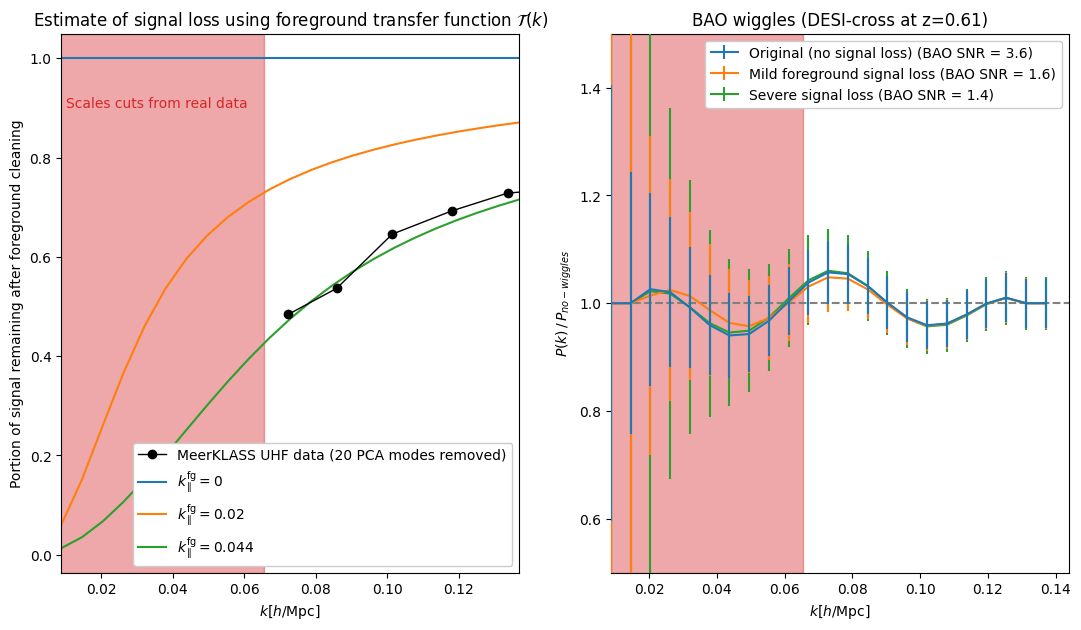

In [5]:
k_fgs = [0,0.02,0.044] # different signal loss to apply, from none, to severe

z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky,A_skyX=A_skyX,t_tot=t_obs,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))
k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_skyX,kmax=kmax,Taruya=True)

### First compare signal loss models to real estimates from MeerKLASS data:
plt.figure(figsize=(13,7))
plt.subplot(121)
MKdata = np.load('/Users/sadmin/Documents/ilifu_share/TFs_for_BAO_forecast.npz') # load MeerKLASS UHF DESI1 foreground transfer function
k_dat,TFs,Nfgs = MKdata['k'],MKdata['TF'],MKdata['Nfg']
indx = -3
plt.plot(k_dat,TFs[indx],'-o',label='MeerKLASS UHF data (%s PCA modes removed)'%Nfgs[indx],lw=1,color='black',zorder=10)
kcut = k_dat[0]-np.diff(k_dat)[0]/2 # kcuts applied to data
# Fit signal loss models B_fg:
mu = np.linspace(0,1,1000)
kgrid,mugrid = np.meshgrid(k,mu)
from scipy.special import legendre as Leg
import scipy
for i in range(len(k_fgs)):
    B_fg_1d = scipy.integrate.simpson( model.B_fg(kgrid,mugrid,k_fgs[i]) * Leg(0)(mugrid) , x=mu, axis=0 )  # integrate over mu axis (axis=0)
    plt.plot(k,B_fg_1d,label=r'$k_\parallel^{\rm fg}=%s$'%k_fgs[i])
plt.xlim(k[0],k[-1])
plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'Portion of signal remaining after foreground cleaning')
plt.title(r'Estimate of signal loss using foreground transfer function $\mathcal{T}(k)$')
plt.axvspan(0,kcut,color='tab:red',alpha=0.4)
plt.legend(framealpha=1)
plt.text(0.01,0.9,'Scales cuts from real data',color='tab:red')
                                   
### Then analyse impact of signal loss on BAO wiggles:
plt.subplot(122)
labels = ['Original (no signal loss)','Mild foreground signal loss','Severe signal loss']
for i in range(len(k_fgs)):
    surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fgs[i]
    P_X = model.P_ell(0,k,Pmod,cosmopars,surveypars,nuispars,'X')
    P_err = model.sigma_ell_error(0,k,Pmod,cosmopars,surveypars,nuispars,'X')
    P_smooth,f_BAO_HI_wb = model.Pk_noBAO(P_X,k)

    if k_fgs[i]==0: k_wcuts = k # no cuts
    else: k_wcuts = k[k>kcut] # apply cuts from data
    
    F = fisher.Matrix_ell(theta_ids,k_wcuts,Pmod,cosmopars,surveypars,nuispars,ells,tracer='X')
    C = fisher.FisherInverse(F)
    SNR_BAO = 1/np.sqrt(C[-1][-1])
    print('Cross ( z =',z,'):',SNR_BAO)

    plt.errorbar(k,P_X/P_smooth,P_err/P_smooth,label=labels[i] + ' (BAO SNR = %s)'%np.round(SNR_BAO,1),zorder=10-i)

plt.axvspan(0,kcut,color='tab:red',alpha=0.4)
plt.axhline(1,color='gray',ls='--')
plt.xlabel(r'$k [h/{\rm Mpc}]$')
plt.ylabel(r'$P(k)\,/\,P_{no-wiggles}$')
plt.title('BAO wiggles (DESI-cross at z=%s)'%z)
plt.ylim(0.5,1.5)
plt.xlim(left=k[0])
plt.legend(framealpha=1)
plt.show()

### Visualise on a grid the impact of observing time and sky area on BAO SNR:

9, 9

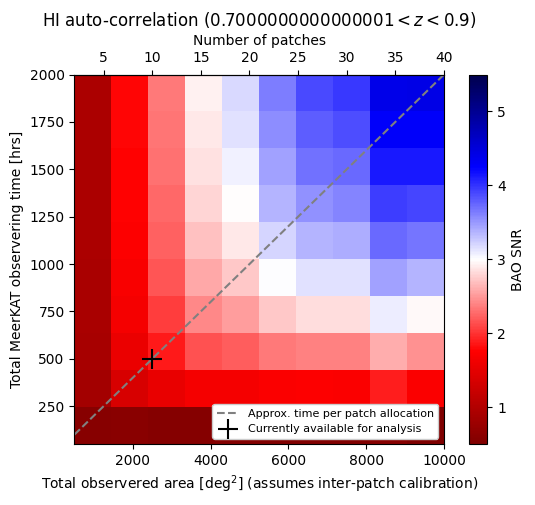

In [6]:
k_fg = 0 # run with no signal loss

A_skys = np.linspace(500,10000,10)
t_obss_noloss = np.linspace(50,2000,10) # total MeerKLASS observation times
t_obss = t_obss_noloss * (1-f_tobsloss) # MeerKLASS observation times (with losses then applied)

SNR_BAO = np.zeros((len(A_skys),len(t_obss)))
for i,A_sky_i in enumerate(A_skys):
    for j,t_obs_j in enumerate(t_obss):
        sys.stdout.write(f"\r{i}, {j}")
        sys.stdout.flush()

        z,zmin1,zmin2,zmax1,zmax2,A_sky1,A_sky2,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,t_tot,N_dish,sigma_z1,sigma_z2,P_N,nbar = survey.params(Survey1=Survey1_arg,Survey2=Survey2_arg,zminzmax=zminzmax,A_sky1=A_sky_i,A_skyX=A_sky_i,t_tot=t_obs_j,N_dish=N_dish,T_sys=model.Tsys(np.mean(zminzmax)))
        surveypars = z,V_bin1,V_bin2,V_binX,theta_FWHM1,theta_FWHM2,sigma_z1,sigma_z2,P_N,1/nbar,k_fg
        cosmopars = cosmo.SetCosmology(z=z,return_cosmopars=True,ZesVersion=ZesVersion) # set initial default cosmology

        Pmod = cosmo.MatterPk(z)
        k,kbins,kmin,kmax = model.get_kbins(z,zminzmax[0],zminzmax[1],A_sky=A_sky_i,kmax=kmax,Taruya=True)
        F = fisher.Matrix_ell(theta_ids,k,Pmod,cosmopars,surveypars,nuispars,ells,tracer='1')
        C = fisher.FisherInverse(F)
        SNR_BAO[i,j] = 1/np.sqrt(C[-1][-1])

aspect = (A_skys[-1]-A_skys[0]) / (t_obss_noloss[-1]-t_obss_noloss[0]) # square aspect pixels
plt.imshow(SNR_BAO.T,origin='lower',extent=[A_skys[0],A_skys[-1],t_obss_noloss[0],t_obss_noloss[-1]],aspect=aspect,vmin=0.5,vmax=5.5,cmap='seismic_r')
plt.colorbar(label='BAO SNR')

ax = plt.gca()
areaperpatch = 250 # assume area per patch [deg2] to create Number of patches axis:
def area_to_patches(A):
    return A / areaperpatch
def patches_to_area(N):
    return N * areaperpatch
secax = ax.secondary_xaxis('top', functions=(area_to_patches, patches_to_area))
secax.set_xlabel('Number of patches')

## Add current time allocation 1D line:
A_skyX_fid = np.linspace(A_skys[0],A_skys[-1],100)
t_single_patch = 50 # hours
t_obs_fid = t_single_patch * A_skyX_fid/areaperpatch # approximately we do t_single_patch hrs of observations per 250deg2 patch?
plt.plot(A_skyX_fid,t_obs_fid,color='gray',ls='--',label='Approx. time per patch allocation')
plt.xlim(A_skys[0],A_skys[-1])
plt.ylim(t_obss_noloss[0],t_obss_noloss[-1])

## Add marker to identify where we are now:
currentnpatch = 10 # how many patches do we currently have ready to analyse 
plt.scatter(currentnpatch*areaperpatch, t_single_patch * currentnpatch,zorder=10,marker='+',s=200,color='black',label='Currently available for analysis')

plt.legend(fontsize=8,framealpha=1,loc='lower right')
plt.xlabel(r'Total observered area [deg$^2$] (assumes inter-patch calibration)')
plt.ylabel('Total MeerKAT observering time [hrs]')
plt.title(r'HI auto-correlation ($%s{<}z{<}%s$)'%(zminzmax[0],zminzmax[1]))
plt.show()